In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Any results you write to the current directory are saved as output.
from numpy import array
import torch
import gc
import torch.nn as nn
import sys
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from core.util.get_datasets import get_park_dataset, get_one_park_dataset

In [2]:
batch_size = 64
learning_rate = 0.005
EPOCHS = 125
lookback = 24
loss_function = nn.HuberLoss()

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
x_train, y_train, x_val, y_val, x_test, y_test = get_one_park_dataset(24, 24, 1)
x_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train).float()
x_val = torch.tensor(x_val).float()
y_val = torch.tensor(y_val).float()
x_test = torch.tensor(x_test).float()
y_test = torch.tensor(y_test).float()

In [5]:
class TreforData(Dataset):
    """Initialize Trefor dataset."""

    def __init__(self, x: torch.tensor, y: torch.tensor) -> None:
        """Initialize dataset.

        Arguments:
            x: feature as torch
            y: target as torch

        """
        self.x = x.to(device)
        self.y = y.to(device)

    def __len__(self) -> int:
        """Return length of dataset."""
        return len(self.x)

    def __getitem__(self, i: int) -> tuple:
        """Return tuple from dataset."""
        return self.x[i], self.y[i]


train_dataset = TreforData(x_train, y_train)
val_dataset = TreforData(x_val, y_val)
test_dataset = TreforData(x_test, y_test)

In [6]:
training_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testing_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
class ParallelCNNLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(ParallelCNNLSTMModel, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(out_features=128),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc_lstm = nn.Linear(hidden_size, 128)
        self.fc = nn.Linear(128*2, num_classes)

    def forward(self, x):
        #cnn takes input of shape (batch_size, channels, seq_len)
        x_cnn = x.permute(0, 2, 1)
        out_cnn = self.cnn(x_cnn)
        # lstm takes input of shape (batch_size, seq_len, input_size)
        out_lstm, _ = self.lstm(x)
        out_lstm = self.fc_lstm(out_lstm[:, -1, :])
        out = torch.cat([out_cnn, out_lstm], dim=1)
        out = self.fc(out)
        return out

In [8]:
model = ParallelCNNLSTMModel(1,5,6,24).to(device)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
plot_train_loss = []
plot_val_loss = []


def train_one_epoch() -> float:
    """Train one epoch."""
    running_loss = 0.0
    last_loss = 0.0

    for i, data in enumerate(training_loader):
        # Every data instance is an input + target
        inputs, target = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        predictions = model(inputs)

        # Compute the loss and its gradient
        target = target.squeeze(-1)
        loss = loss_function(predictions, target)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 100 == 99:
            last_loss = running_loss / 100  # loss per 100 batch
            # print(f'  batch {i+1} loss: {last_loss}')
            running_loss = 0.0
    return last_loss



In [10]:
epoch_number = 0
best_v_loss = sys.maxsize
best_model = None


for epoch in tqdm(range(EPOCHS), desc="Iterating epochs"):
    model.train()
    avg_loss = train_one_epoch()

    model.eval()
    with torch.no_grad():
        running_v_loss = 0.0
        for i, v_data in enumerate(validation_loader):
            v_inputs, v_target = v_data
            v_predictions = model(v_inputs)
            v_target = v_target.squeeze(-1)
            v_loss = loss_function(v_predictions, v_target)
            running_v_loss += v_loss.item()

    avg_v_loss = running_v_loss / (i + 1)
    plot_train_loss.append(avg_loss)
    plot_val_loss.append(avg_v_loss)

    optimizer.step()

    if avg_v_loss < best_v_loss:
        best_v_loss = avg_v_loss
        best_model = copy.deepcopy(model)

Iterating epochs: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:59<00:00,  2.11it/s]


In [11]:
best_model.eval()
predicted = []
t_loss = 0
num_batches = len(testing_loader)
size = len(testing_loader.dataset)
with torch.no_grad():
    for i, t_data in enumerate(testing_loader):
        t_inputs, t_target = t_data
        t_predictions = best_model(t_inputs)
        predicted.append(t_predictions)
        t_loss += loss_function(t_predictions, t_target).item()

predicted = torch.cat(predicted, dim=0)
t_loss /= num_batches
print(f"Avg loss: {t_loss:>8f} \n")

Avg loss: 0.004776 



/home/absentia/projects/zap/venv/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1123: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1410.)
  result = _VF.lstm(


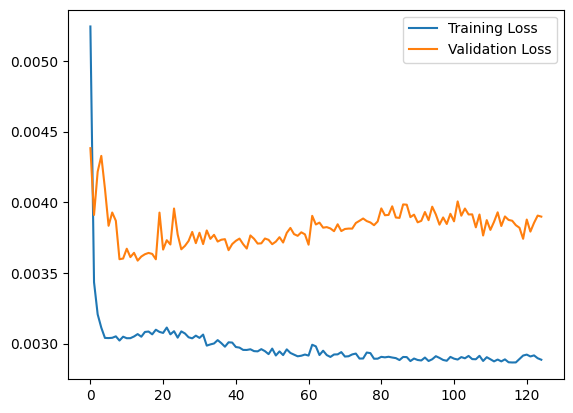

In [12]:
plt.clf()
plt.plot(plot_train_loss, label="Training Loss")
plt.plot(plot_val_loss, label="Validation Loss")
plt.legend()
plt.show()

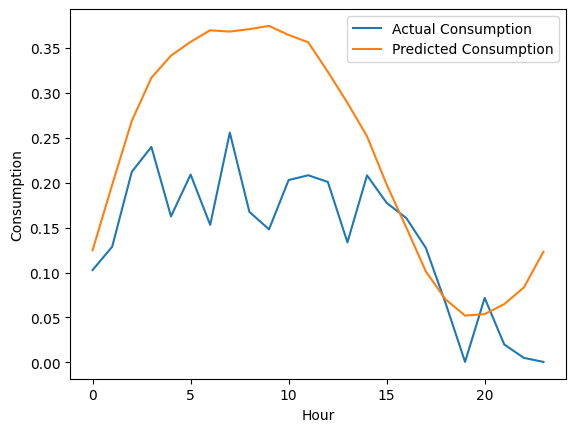

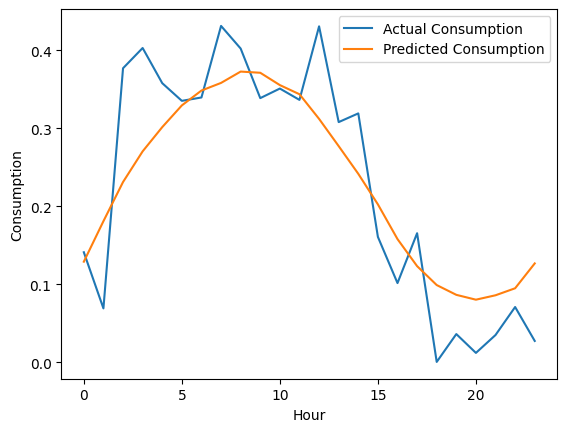

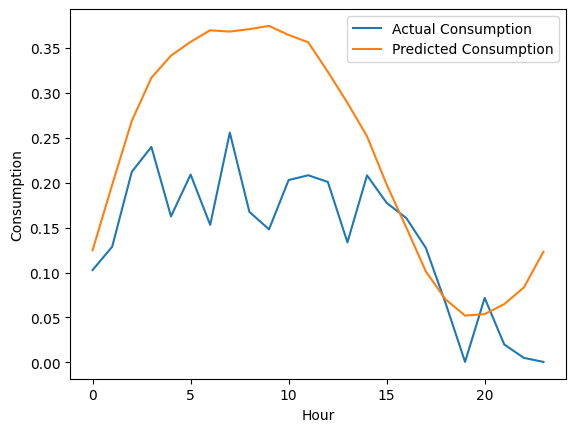

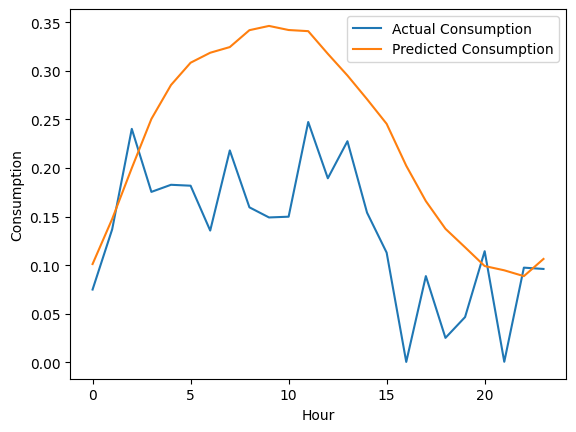

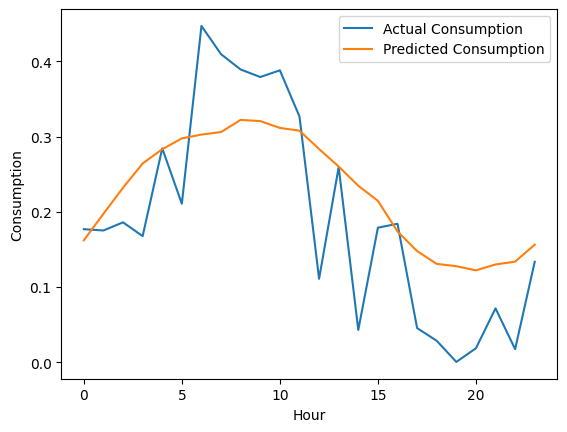

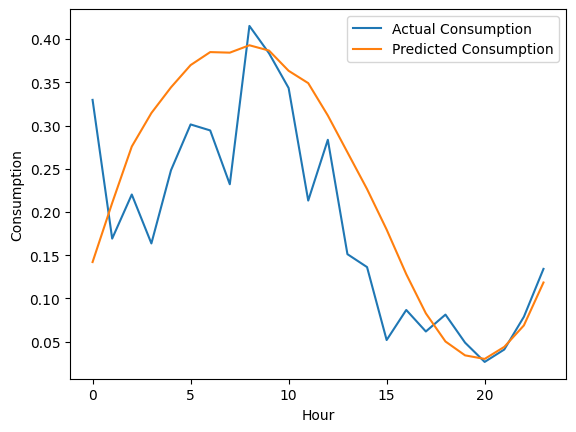

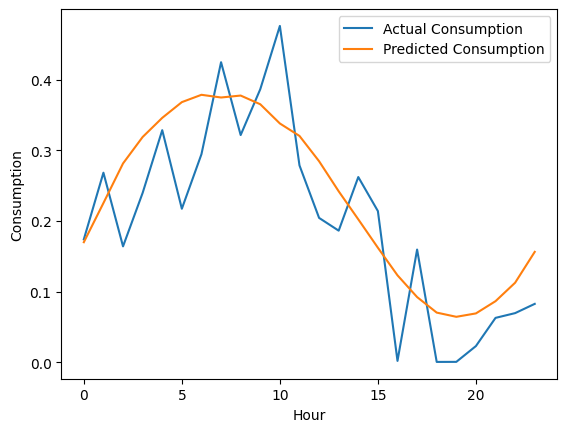

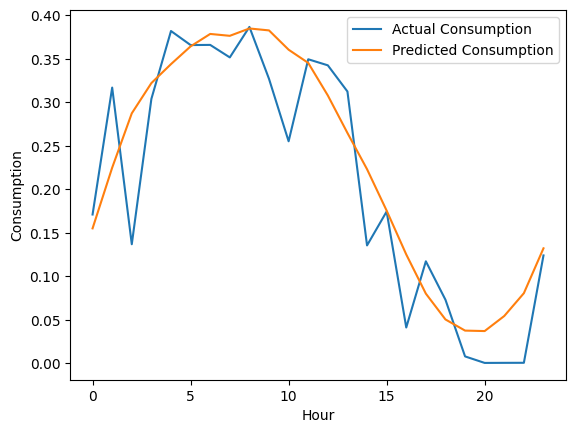

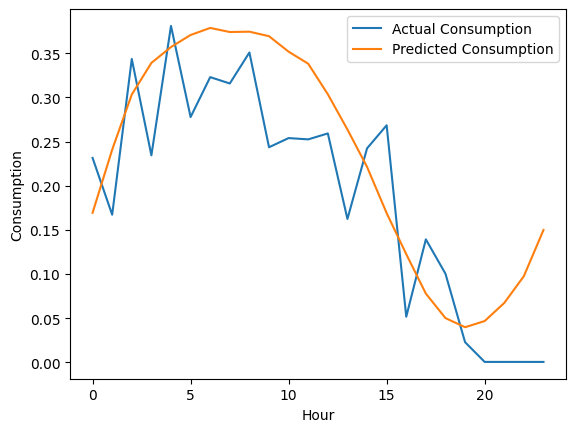

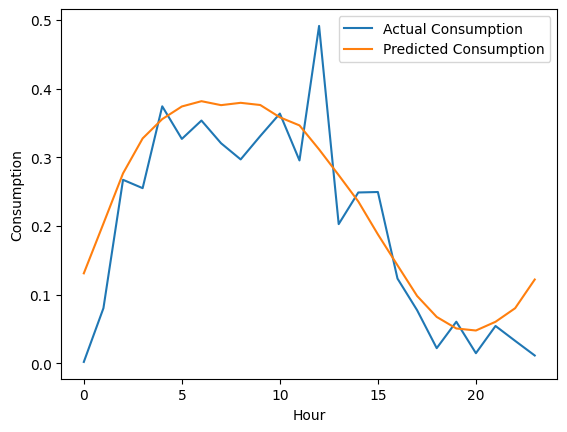

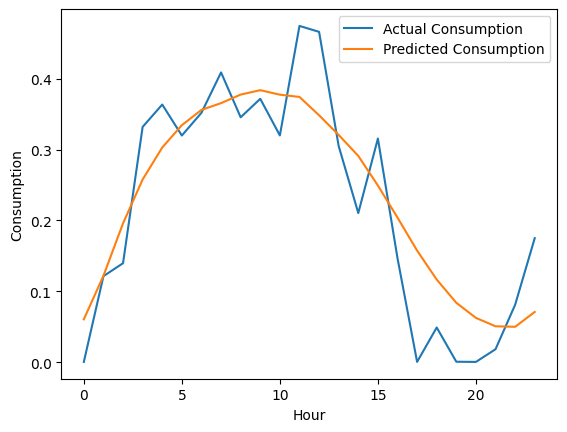

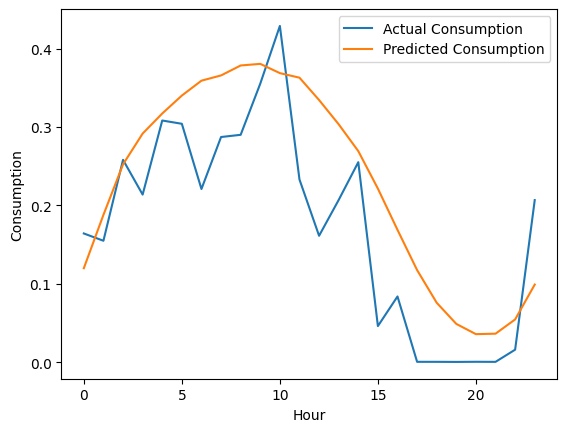

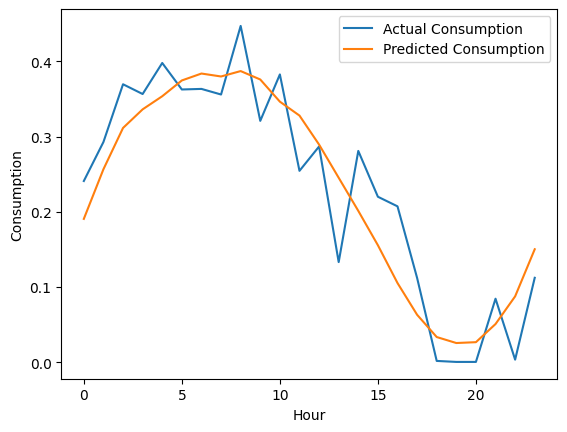

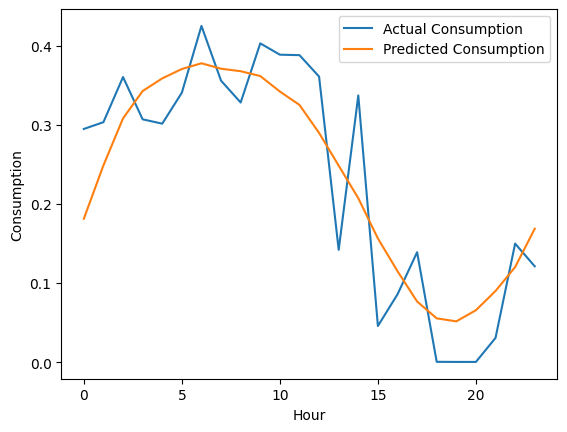

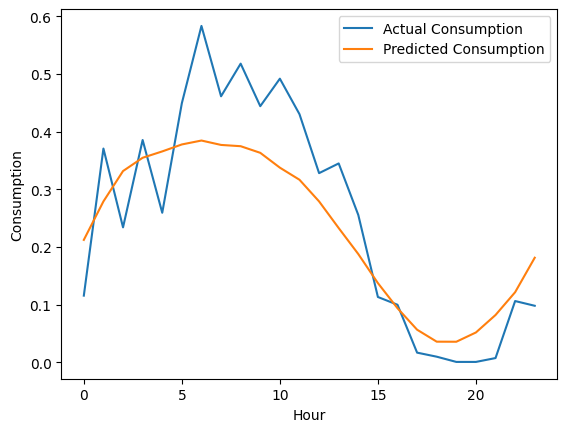

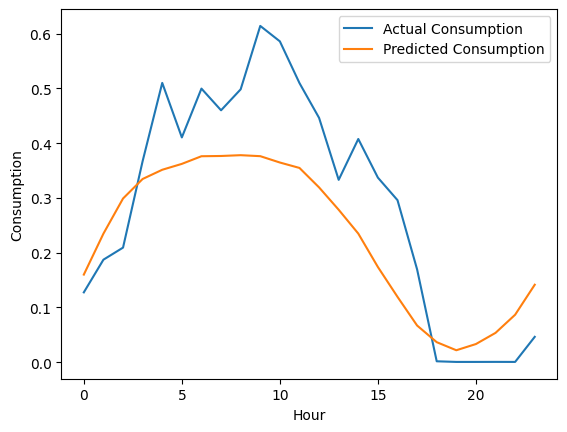

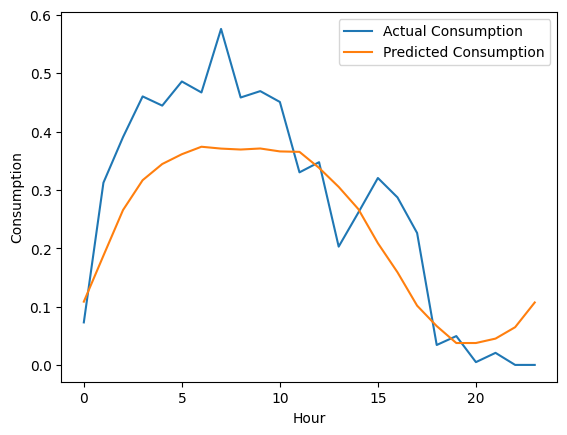

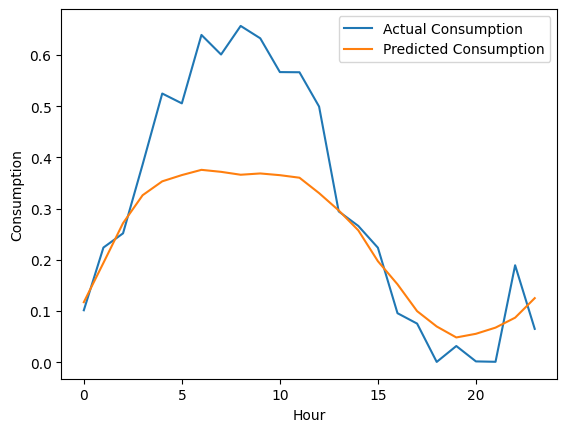

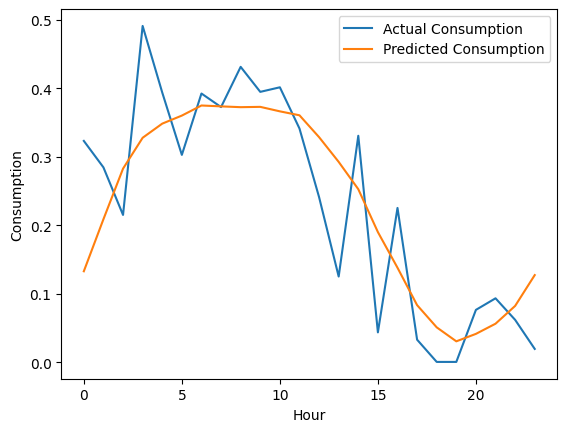

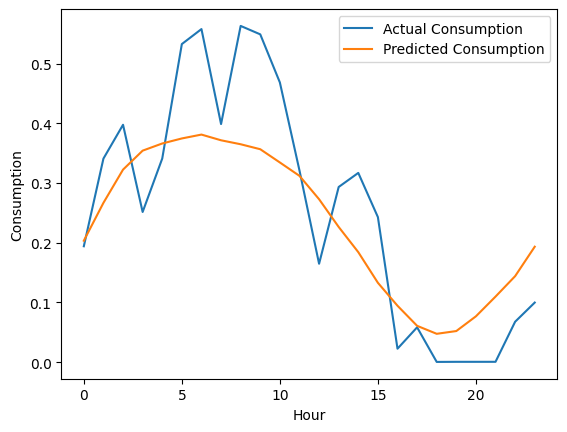

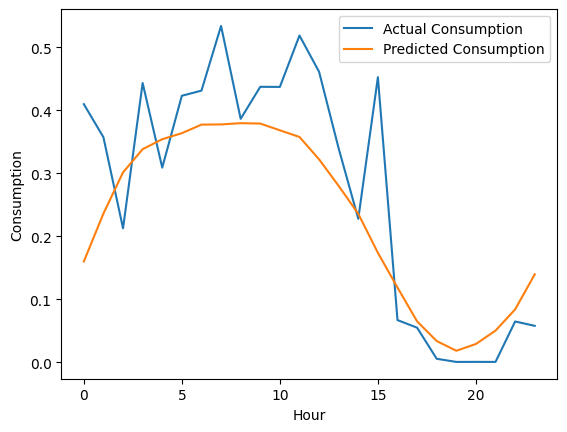

In [15]:
y = y_test[24].flatten()
prediction = predicted[24].flatten().to("cpu")

plt.plot(y, label="Actual Consumption")
plt.plot(prediction, label="Predicted Consumption")
plt.xlabel("Hour")
plt.ylabel("Consumption")
plt.legend()
plt.show()

for i in range(20):
    plt.plot(y_test[i * 24].flatten(), label="Actual Consumption")
    plt.plot(predicted[i * 24].flatten().to("cpu"), label="Predicted Consumption")
    plt.xlabel("Hour")
    plt.ylabel("Consumption")
    plt.legend()
    plt.show()